In [1]:
import torch
print(torch.cuda.is_available())   # should be True
print(torch.version.cuda)          # CUDA version PyTorch is built with
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else None
print(torch.cuda.device_count())
import os
os.cpu_count()

True
11.7
NVIDIA RTX 6000 Ada Generation
2


48

In [2]:
import scanpy as sc

# Load your dataset
adata_4i = sc.read_h5ad("4i/8h.h5ad")

# Basic overview
print(adata_4i)
print("Shape:", adata_4i.shape)

# View column names (metadata about each cell)
print("Observation columns:", adata_4i.obs.columns.tolist()[:10])
print("Feature columns:", adata_4i.var_names[:10].tolist())

# How many drugs (conditions)?
print("Unique conditions:", adata_4i.obs['drug'].unique())
print("Number of cells per condition:")
print(adata_4i.obs['drug'].value_counts())



AnnData object with n_obs × n_vars = 119479 × 78
    obs: 'drug'
    var: 'cell_part', 'measurement', 'stat', 'feature', 'original'
    uns: 'source'
Shape: (119479, 78)
Observation columns: ['drug']
Feature columns: ['morphology-nuclei-area', 'morphology-nuclei-circularity', 'morphology-nuclei-convexity', 'morphology-nuclei-eccentricity', 'morphology-nuclei-elongation', 'morphology-nuclei-equivalent_diameter', 'morphology-nuclei-extent', 'morphology-nuclei-major_axis_length', 'morphology-nuclei-mean_radius', 'morphology-nuclei-perimeter']
Unique conditions: ['ixazomib', 'everolimus', 'olaparib', 'paclitaxel', 'vemurafenib_cobimetinib', ..., 'ixazomib_lenalidomide_dexamethasone', 'melphalan', 'ulixertinib', 'dasatinib', 'sec.abcl']
Length: 38
Categories (38, object): ['cisplatin', 'cisplatin_olaparib', 'cl', 'control', ..., 'trametinib_panobinostat', 'ulixertinib', 'vemurafenib_cobimetinib', 'vindesine']
Number of cells per condition:
cl                                        18332
con

In [3]:
features_4i = [
    "intensity-cell-CD45-mean",
    "intensity-cell-ClCasp3-mean",
    "intensity-cell-DAPI-sum",
    "intensity-cell-Ki67-mean",
    "intensity-cell-MelA-mean",
    "intensity-cell-PCNA-mean",
    "intensity-cell-Sox9-mean",
    "intensity-cell-aTUB-mean",
    "intensity-cell-pAKT-mean",
    "intensity-cell-pEGFR-mean",
    "intensity-cell-pERK-mean",
    "intensity-cell-pMET-mean",
    "intensity-cell-pS6k1-mean",
    "intensity-nuclei-CD45-mean",
    "intensity-nuclei-ClCasp3-mean",
    "intensity-nuclei-DAPI-sum",
    "intensity-nuclei-Ki67-mean",
    "intensity-nuclei-MelA-mean",
    "intensity-nuclei-PCNA-mean",
    "intensity-nuclei-Sox9-mean",
    "intensity-nuclei-aTUB-mean",
    "intensity-nuclei-pAKT-mean",
    "intensity-nuclei-pEGFR-mean",
    "intensity-nuclei-pERK-mean",
    "intensity-nuclei-pMET-mean",
    "intensity-nuclei-pS6k1-mean",
    "morphology-cell-area",
    "morphology-cell-circularity",
    "morphology-cell-convexity",
    "morphology-cell-eccentricity",
    "morphology-cell-elongation",
    "morphology-cell-equivalent_diameter",
    "morphology-cell-extent",
    "morphology-cell-major_axis_length",
    "morphology-cell-mean_radius",
    "morphology-cell-perimeter",
    "morphology-cell-roundness",
    "morphology-nuclei-area",
    "morphology-nuclei-circularity",
    "morphology-nuclei-convexity",
    "morphology-nuclei-eccentricity",
    "morphology-nuclei-elongation",
    "morphology-nuclei-equivalent_diameter",
    "morphology-nuclei-extent",
    "morphology-nuclei-major_axis_length",
    "morphology-nuclei-mean_radius",
    "morphology-nuclei-perimeter",
    "morphology-nuclei-roundness"
]


In [4]:
import os
import sys
import json
import logging
import argparse
import geomloss
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List, Optional
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from typing import Dict, Tuple, List
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

import gc
gc.collect()

def median_heuristic_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Median heuristic for RBF bandwidth: gamma = 1 / median(||x - y||^2).
    Uses the median of pairwise distances in the pooled set.
    """
    Z = np.vstack([X, Y])
    # Sample if too large for efficiency
    max_samples = 5000
    if Z.shape[0] > max_samples:
        idx = np.random.choice(Z.shape[0], size=max_samples, replace=False)
        Z = Z[idx]
    D2 = cdist(Z, Z, metric='sqeuclidean')
    # Use upper triangular without diagonal
    triu = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / max(med, 1e-12)

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)

def r2_feature_means(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    R^2 computed across features between mean vectors of y_true and y_pred.
    """
    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    ss_res = float(np.sum((mu_true - mu_pred) ** 2))
    ss_tot = float(np.sum((mu_true - mu_true.mean()) ** 2))
    if ss_tot <= 1e-12:
        return 1.0 if ss_res <= 1e-12 else 0.0
    return 1.0 - ss_res / ss_tot

def wasserstein_pointcloud(
    X,
    Y,
    p: int = 2,
    a=None,
    b=None,
    method: str = "emd",          # "emd" (exact) or "sinkhorn" (approx)
    reg: float = 1e-1,            # Sinkhorn regularization (only used if method="sinkhorn")
    return_plan: bool = False,
):
    """
    Compute Wasserstein distance W_p between two empirical distributions supported on point sets X and Y.

    Parameters
    ----------
    X : (n, d) array-like
        Source points.
    Y : (m, d) array-like
        Target points.
    p : int
        Order of the Wasserstein distance (commonly 1 or 2).
    a : (n,) array-like or None
        Weights for X; if None, uniform weights.
    b : (m,) array-like or None
        Weights for Y; if None, uniform weights.
    method : str
        "emd" for exact optimal transport (requires POT),
        "sinkhorn" for entropic approximation (requires POT).
    reg : float
        Entropic regularization strength for Sinkhorn.
    return_plan : bool
        If True, also return the optimal transport plan.

    Returns
    -------
    Wp : float
        Wasserstein distance of order p.
    plan : (n, m) ndarray, optional
        Optimal transport plan (only if return_plan=True).
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays with shape (n, d) and (m, d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: X has d={X.shape[1]}, Y has d={Y.shape[1]}.")

    n, d = X.shape
    m, _ = Y.shape

    if a is None:
        a = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        a = np.asarray(a, dtype=np.float64)
        a = a / a.sum()

    if b is None:
        b = np.full(m, 1.0 / m, dtype=np.float64)
    else:
        b = np.asarray(b, dtype=np.float64)
        b = b / b.sum()

    # Cost matrix: C_ij = ||x_i - y_j||^p
    # Compute squared Euclidean via (x-y)^2 = x^2 + y^2 - 2xy for speed
    X2 = np.sum(X * X, axis=1, keepdims=True)          # (n, 1)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T        # (1, m)
    sq = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)     # (n, m)
    if p == 2:
        C = sq
    else:
        C = sq ** (p / 2.0)

    try:
        import ot  # POT: Python Optimal Transport
    except ImportError as e:
        raise ImportError(
            "This function requires the POT library. Install with: pip install pot"
        ) from e

    method = method.lower()
    if method == "emd":
        # exact OT: minimizes <P, C>
        P = ot.emd(a, b, C)
        cost = float(np.sum(P * C))
    elif method == "sinkhorn":
        # entropic OT approximation
        P = ot.sinkhorn(a, b, C, reg=reg)
        cost = float(np.sum(P * C))
    else:
        raise ValueError('method must be either "emd" or "sinkhorn".')

    Wp = cost ** (1.0 / p)

    if return_plan:
        return Wp, P
    return Wp

def summarize_metrics(y_true: np.ndarray, y_pred: np.ndarray, median_gamma: float) -> dict:
    """
    Compute a standard set of metrics: MMD^2 (RBF), R^2 of feature means, median KS across features, and Wasserstein distance.
    """
    # Drop any samples that contain NaNs in either true or pred
    mask = (~np.isnan(y_true).any(axis=1)) & (~np.isnan(y_pred).any(axis=1))
    if mask.sum() < len(y_true):
        print(f"[summarize_metrics] Dropping {len(y_true) - mask.sum()} samples with NaNs.")
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    out = {}

    out['mmd2_gamma_median'] = mmd_distance(y_true, y_pred, gamma=median_gamma)
    out['mmd2_gamma_0.5'] = mmd_distance(y_true, y_pred, gamma=0.5)
    out['mmd2_gamma_1.0'] = mmd_distance(y_true, y_pred, gamma=1.0)
    out['wasserstein_distance'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="emd")
    out['R2_feature_means'] = r2_feature_means(y_true, y_pred)
    return out

def split_train_test(X: np.ndarray, Y: np.ndarray, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if X.shape[0] != Y.shape[0]:
        min_len = min(len(X), len(Y))
        X = X[:min_len]
        Y = Y[:min_len]

    n = X.shape[0]
    n_train = max(1, int(n * train_fraction))
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    tr_idx, te_idx = idx[:n_train], idx[n_train:]
    return X[tr_idx], X[te_idx], Y[tr_idx], Y[te_idx]

def topk_markers(adata, drug: str, k: int = 50, rank_key: str = "marker_genes-drug-rank"):
    R = adata.varm[rank_key]

    # --- get the rank vector for this drug ---
    if hasattr(R, "columns") and hasattr(R, "iloc"):  # pandas DataFrame
        if drug in R.columns:
            r = R[drug].to_numpy()
        else:
            # fallback: interpret columns as ordered groups; try to map via rank_genes_groups names
            names = adata.uns["rank_genes_groups"]["names"]
            groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
            r = R.iloc[:, groups.index(drug)].to_numpy()
    else:  # numpy array (or array-like)
        names = adata.uns["rank_genes_groups"]["names"]
        groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
        r = np.asarray(R)[:, groups.index(drug)]

    # smaller rank => stronger marker
    idx = np.argsort(r)[:k]
    gene_ids = adata.var_names[idx].to_list()
    gene_short = (adata.var.iloc[idx]["gene_short_name"].to_list()
                  if "gene_short_name" in adata.var.columns else None)
    return gene_ids, gene_short, idx


In [7]:
import sys
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from cellot.models.cellot import load_networks, compute_loss_f, compute_loss_g

from sklearn.metrics.pairwise import rbf_kernel


def mmd_distance(x, y, gamma):
    xx = rbf_kernel(x, x, gamma)
    xy = rbf_kernel(x, y, gamma)
    yy = rbf_kernel(y, y, gamma)

    return xx.mean() + yy.mean() - 2 * xy.mean()

def compute_mmd_loss(lhs, rhs, gammas):
    return np.mean([mmd_distance(lhs, rhs, g) for g in gammas])

from cellot.losses.mmd import mmd_distance

def run_cellot_pair(train_pre: np.ndarray, train_post: np.ndarray,
                    test_pre: np.ndarray, test_post: np.ndarray,
                    layers: Optional[List[int]] = [32, 32, 32],
                    n_epochs: int = 5000,
                    feature_subset: Optional[List[int]] = None,) -> Dict:
    
    device = 'cuda'
    print(f"VERS torch={torch.__version__} (CellOT), device={device}", file=sys.stderr, flush=True)


    # Apply feature subset if specified
    if feature_subset is not None:
        print(f"Using feature subset of size {len(feature_subset)}", file=sys.stderr, flush=True)
        train_pre = train_pre[:, feature_subset]
        train_post = train_post[:, feature_subset]
        test_pre = test_pre[:, feature_subset]
        test_post = test_post[:, feature_subset]

    # Preprocess: standardize jointly and optionally apply PCA for stability
    X_all = np.vstack([train_pre, train_post])
    scaler = StandardScaler()
    X_all_s = scaler.fit_transform(X_all)
    d = X_all_s.shape[1]
    pca_dims = min(50, d)
    if pca_dims < d:
        pca = PCA(n_components=pca_dims, svd_solver='full', random_state=42)
        X_all_p = pca.fit_transform(X_all_s)
        tr_pre_p = X_all_p[:len(train_pre)]
        tr_post_p = X_all_p[len(train_pre):]
        te_pre_p = pca.transform(scaler.transform(test_pre))
        use_pca = True
    else:
        tr_pre_p = X_all_s[:len(train_pre)]
        tr_post_p = X_all_s[len(train_pre):]
        te_pre_p = scaler.transform(test_pre)
        use_pca = False

    # Networks - Using official CellOT configuration
    input_dim = tr_pre_p.shape[1]
    config = {
        'model': {
            'name': 'cellot',
            'hidden_units': layers,
            'kernel_init_fxn': {'name': 'uniform', 'a': -0.01, 'b': 0.01},
            'activation': 'relu',
            'softplus_W_kernels': True,
            'f': {},
            'g': {}
        }
    }
    f, g = load_networks(config, input_dim=input_dim)
    f = f.to(device).float()
    g = g.to(device).float()

    # Data tensors
    src = torch.tensor(tr_pre_p, dtype=torch.float32, device=device)
    tgt = torch.tensor(tr_post_p, dtype=torch.float32, device=device)
    te_src = torch.tensor(te_pre_p, dtype=torch.float32, device=device)

    # Optimizers matching official config
    lr = 1e-4
    optim_f = torch.optim.Adam(f.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)
    optim_g = torch.optim.Adam(g.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)

    # No schedulers in official config
    # n_epochs = 1200  # More epochs for better convergence
    n_epochs = n_epochs + 1  
    # Training loop following official CellOT implementation
    f.train(); g.train()
    batch_size = 256  # Official config
    n_inner_iters = 10  # Official config


    for epoch in range(n_epochs):
        f.train(); g.train()
        perm_t = torch.randperm(len(tgt), device=device)[:batch_size]
        yt = tgt[perm_t]
        
        # Multiple g updates per iteration (official implementation)
        for _ in range(n_inner_iters):
            perm_s = torch.randperm(len(src), device=device)[:batch_size]
            xs = src[perm_s].detach().clone().requires_grad_(True)
            
            optim_g.zero_grad()
            g_loss = compute_loss_g(f, g, xs).mean()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(g.parameters(), max_norm=0.5)
            optim_g.step()
        
        # Single f update (official implementation)
        perm_s = torch.randperm(len(src), device=device)[:batch_size]
        xs = src[perm_s].detach().clone().requires_grad_(True)
        
        optim_f.zero_grad()
        f_loss = compute_loss_f(f, g, xs, yt).mean()
        f_loss.backward()
        optim_f.step()
        
        # Clamp weights for f (official implementation)
        if hasattr(f, 'clamp_w'):
            f.clamp_w()
        
        
        # ---- Evaluate train MMD and early-stop ----
        if epoch % 50 == 0: 
            f.eval()
            g.eval()


            # Transport a fixed subset of training PRE (in preprocessed space)
            tr_src_eval = src.requires_grad_(True)
            tr_pred_p = g.transport(tr_src_eval).detach().cpu().numpy()
            # Invert preprocessing to original space (so MMD is comparable to your final eval)
            if use_pca:
                tr_pred = scaler.inverse_transform(pca.inverse_transform(tr_pred_p))
            else:
                tr_pred = scaler.inverse_transform(tr_pred_p)
            train_mmd_min = mmd_distance(train_post, tr_pred, gamma=1.0)


            te_src_full = te_src.detach().clone().requires_grad_(True)
            te_pred_full = g.transport(te_src_full).detach().cpu().numpy()
            if use_pca:
                te_pred_inv_full = scaler.inverse_transform(pca.inverse_transform(te_pred_full))
            else:
                te_pred_inv_full = scaler.inverse_transform(te_pred_full)
            test_metrics = mmd_distance(test_post, te_pred_inv_full, gamma=median_gamma)

            print(
                f"[CellOT] epoch={epoch} f_loss={f_loss.item():.4f} g_loss={g_loss.item():.4f} | "
                f"train mmd={train_mmd_min:.4f} | "
                f"test_mmd={test_metrics:.4f}",
                file=sys.stderr,
                flush=True,
            )

                
            

    # Inference (CellOT transport requires gradients for autodiff)
    f.eval(); g.eval()
    # CellOT needs gradients even in eval mode for transport computation
    te_src_for_transport = te_src.detach().clone().requires_grad_(True)
    te_tx = g.transport(te_src_for_transport).detach().cpu().numpy()

    # Inverse preprocess
    if use_pca:
        te_tx_inv = scaler.inverse_transform(pca.inverse_transform(te_tx))
    else:
        te_tx_inv = scaler.inverse_transform(te_tx)
    # Final evaluation
    metrics = summarize_metrics(test_post[:len(te_tx_inv)], te_tx_inv, median_gamma)

    gammas = np.logspace(1, -3, num=50)
    mmd = compute_mmd_loss(test_post[:len(te_tx_inv)], te_tx_inv, gammas=gammas)
    print(f"[CellOT] Final CellOT MMD: {mmd:.4f}", file=sys.stderr, flush=True)
    
    return {'y_pred': te_tx_inv, 'metrics': metrics}
    


X_pre cells: (10995, 48)
X_post cells: (2637, 48)
(2109, 48)
(528, 48)
(2109, 48)
(528, 48)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.08064887236416649
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=2.6851 g_loss=-27.1132 | train mmd=0.0264 | test_mmd=0.2325
[CellOT] epoch=50 f_loss=-46.1256 g_loss=-53.3312 | train mmd=0.0158 | test_mmd=0.4378
[CellOT] epoch=100 f_loss=-31.3883 g_loss=-32.6367 | train mmd=0.0158 | test_mmd=0.4147
[CellOT] epoch=150 f_loss=-8.8425 g_loss=-22.0010 | train mmd=0.0157 | test_mmd=0.2323
[CellOT] epoch=200 f_loss=-9.1484 g_loss=-19.3172 | train mmd=0.0141 | test_mmd=0.0694
[CellOT] epoch=250 f_loss=0.0339 g_loss=-18.3367 | train mmd=0.0111 | test_mmd=0.0254
[CellOT] epoch=300 f_loss=-0.9615 g_loss=-21.2505 | train mmd=0.0085 | test_mmd=0.0139
[CellOT] epoch=350 f_loss=-2.8605 g_loss=-19.4390 | train mmd=0.0067 | test_mmd=0.0151
[CellOT] epoch=400 f_loss=-2.5204 g_loss=-17.2976 | train mmd=0.0065 | test_mmd=0.0130
[CellOT] epoch=450 f_loss=-0.1204 g_loss=-15.9278 | train mmd=0.0045 | test_mmd=0.0064
[CellOT] epoch=500 f_loss=2.8224 g_loss=-17.6602 | train mmd=0.0054 | test_mmd=0.0136
[CellOT] epoch=550 f_loss=-1.0918 g_loss=-19.73

Run 0 metrics: {'mmd2_gamma_median': 0.008655770565777932, 'mmd2_gamma_0.5': 0.011748747168152829, 'mmd2_gamma_1.0': 0.008045261350054785, 'wasserstein_distance': 2.2155815046730405, 'R2_feature_means': 0.9538888927663388}
**************** Run: 1 ****************


...

[CellOT] epoch=50 f_loss=-62.7701 g_loss=-60.3537 | train mmd=0.0158 | test_mmd=0.4390
[CellOT] epoch=100 f_loss=-34.3335 g_loss=-27.7905 | train mmd=0.0158 | test_mmd=0.4199
[CellOT] epoch=150 f_loss=-22.1158 g_loss=-20.0770 | train mmd=0.0158 | test_mmd=0.3148
[CellOT] epoch=200 f_loss=-5.8685 g_loss=-20.6087 | train mmd=0.0146 | test_mmd=0.0856
[CellOT] epoch=250 f_loss=-2.6253 g_loss=-18.7626 | train mmd=0.0121 | test_mmd=0.0431
[CellOT] epoch=300 f_loss=-0.0606 g_loss=-15.5406 | train mmd=0.0098 | test_mmd=0.0203
[CellOT] epoch=350 f_loss=0.5888 g_loss=-15.9716 | train mmd=0.0077 | test_mmd=0.0148
[CellOT] epoch=400 f_loss=-0.4083 g_loss=-17.1282 | train mmd=0.0062 | test_mmd=0.0120
[CellOT] epoch=450 f_loss=-5.2857 g_loss=-16.0633 | train mmd=0.0058 | test_mmd=0.0140
[CellOT] epoch=500 f_loss=-2.8852 g_loss=-15.3591 | train mmd=0.0047 | test_mmd=0.0087
[CellOT] epoch=550 f_loss=1.5337 g_loss=-16.1150 | train mmd=0.0042 | test_mmd=0.0087
[CellOT] epoch=600 f_loss=-2.4819 g_loss=-1

Run 8 metrics: {'mmd2_gamma_median': 0.008144609830836425, 'mmd2_gamma_0.5': 0.012023827775998114, 'mmd2_gamma_1.0': 0.008220668540919792, 'wasserstein_distance': 1.8779459635621891, 'R2_feature_means': 0.9631142487249358}
**************** Run: 9 ****************


[CellOT] epoch=50 f_loss=-61.8323 g_loss=-52.9836 | train mmd=0.0158 | test_mmd=0.4380
[CellOT] epoch=100 f_loss=-29.8699 g_loss=-25.3736 | train mmd=0.0158 | test_mmd=0.4148
[CellOT] epoch=150 f_loss=-12.9723 g_loss=-22.6137 | train mmd=0.0158 | test_mmd=0.2219
[CellOT] epoch=200 f_loss=-3.9369 g_loss=-23.0650 | train mmd=0.0148 | test_mmd=0.0799
[CellOT] epoch=250 f_loss=-6.7002 g_loss=-17.5007 | train mmd=0.0126 | test_mmd=0.0402
[CellOT] epoch=300 f_loss=-4.1365 g_loss=-16.8006 | train mmd=0.0101 | test_mmd=0.0192
[CellOT] epoch=350 f_loss=1.8947 g_loss=-19.2808 | train mmd=0.0091 | test_mmd=0.0184
[CellOT] epoch=400 f_loss=-0.1917 g_loss=-17.2448 | train mmd=0.0078 | test_mmd=0.0135
[CellOT] epoch=450 f_loss=0.9770 g_loss=-16.3620 | train mmd=0.0092 | test_mmd=0.0212
[CellOT] epoch=500 f_loss=1.4848 g_loss=-19.1056 | train mmd=0.0066 | test_mmd=0.0144
[CellOT] epoch=550 f_loss=-1.5436 g_loss=-15.9493 | train mmd=0.0052 | test_mmd=0.0073
[CellOT] epoch=600 f_loss=-2.2143 g_loss=-15

Run 9 metrics: {'mmd2_gamma_median': 0.007599399158209508, 'mmd2_gamma_0.5': 0.009228337412555729, 'mmd2_gamma_1.0': 0.006942665991114615, 'wasserstein_distance': 1.963102149620601, 'R2_feature_means': 0.9740436406953892}
                        mean     std
mmd2_gamma_median     0.0076  0.0016
mmd2_gamma_0.5        0.0105  0.0017
mmd2_gamma_1.0        0.0076  0.0008
wasserstein_distance  1.9640  0.1102
R2_feature_means      0.9577  0.0184


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


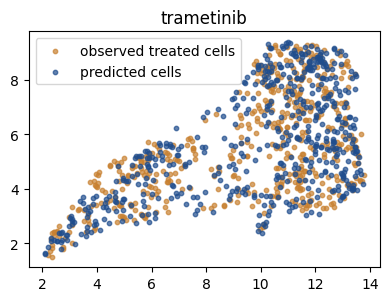

In [12]:
drug = "trametinib"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=1000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post, median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

X_pre cells: (10995, 48)
X_post cells: (2631, 48)
(2104, 48)
(527, 48)
(2104, 48)
(527, 48)


VERS torch=1.13.1+cu117 (CellOT), device=cuda
[CellOT] epoch=0 f_loss=4.8688 g_loss=-24.2287 | train mmd=0.0125 | test_mmd=0.1206


Median heuristic gamma: 0.05748945574198288
**************** Run: 0 ****************


[CellOT] epoch=50 f_loss=-38.5015 g_loss=-47.4504 | train mmd=0.0076 | test_mmd=0.3673
[CellOT] epoch=100 f_loss=-21.1453 g_loss=-32.8385 | train mmd=0.0076 | test_mmd=0.3193
[CellOT] epoch=150 f_loss=-5.6375 g_loss=-23.6190 | train mmd=0.0076 | test_mmd=0.1641
[CellOT] epoch=200 f_loss=0.4531 g_loss=-19.9940 | train mmd=0.0067 | test_mmd=0.0395
[CellOT] epoch=250 f_loss=-2.6327 g_loss=-24.1723 | train mmd=0.0063 | test_mmd=0.0230
[CellOT] epoch=300 f_loss=-6.2283 g_loss=-21.5640 | train mmd=0.0059 | test_mmd=0.0173
[CellOT] epoch=350 f_loss=-3.1856 g_loss=-17.9153 | train mmd=0.0059 | test_mmd=0.0189
[CellOT] epoch=400 f_loss=-2.8536 g_loss=-18.6189 | train mmd=0.0049 | test_mmd=0.0133
[CellOT] epoch=450 f_loss=-1.9457 g_loss=-18.8383 | train mmd=0.0046 | test_mmd=0.0083
[CellOT] epoch=500 f_loss=-3.4331 g_loss=-21.8376 | train mmd=0.0046 | test_mmd=0.0129
[CellOT] epoch=550 f_loss=0.4733 g_loss=-18.4269 | train mmd=0.0036 | test_mmd=0.0096
[CellOT] epoch=600 f_loss=-3.7478 g_loss=-19

Run 0 metrics: {'mmd2_gamma_median': 0.009413500346489578, 'mmd2_gamma_0.5': 0.010724426211362673, 'mmd2_gamma_1.0': 0.006506324849323338, 'wasserstein_distance': 2.135676376521827, 'R2_feature_means': 0.9514483128676121}
**************** Run: 1 ****************


...

[CellOT] epoch=0 f_loss=6.3761 g_loss=-21.1099 | train mmd=0.0192 | test_mmd=0.2387
[CellOT] epoch=50 f_loss=-58.1013 g_loss=-52.0046 | train mmd=0.0076 | test_mmd=0.3753
[CellOT] epoch=100 f_loss=-21.4246 g_loss=-31.4612 | train mmd=0.0076 | test_mmd=0.3601
[CellOT] epoch=150 f_loss=-18.0607 g_loss=-23.1458 | train mmd=0.0076 | test_mmd=0.2660
[CellOT] epoch=200 f_loss=-5.7292 g_loss=-23.9702 | train mmd=0.0074 | test_mmd=0.0754
[CellOT] epoch=250 f_loss=-4.4945 g_loss=-22.9465 | train mmd=0.0068 | test_mmd=0.0341
[CellOT] epoch=300 f_loss=-1.3224 g_loss=-19.7411 | train mmd=0.0065 | test_mmd=0.0204
[CellOT] epoch=350 f_loss=-0.8811 g_loss=-19.0464 | train mmd=0.0061 | test_mmd=0.0191
[CellOT] epoch=400 f_loss=-3.2340 g_loss=-18.4728 | train mmd=0.0059 | test_mmd=0.0144
[CellOT] epoch=450 f_loss=-4.3790 g_loss=-18.6850 | train mmd=0.0055 | test_mmd=0.0127
[CellOT] epoch=500 f_loss=1.0099 g_loss=-19.4200 | train mmd=0.0052 | test_mmd=0.0097
[CellOT] epoch=550 f_loss=-1.2551 g_loss=-17.

Run 8 metrics: {'mmd2_gamma_median': 0.009168443652517788, 'mmd2_gamma_0.5': 0.00931574637041506, 'mmd2_gamma_1.0': 0.0059296488130115505, 'wasserstein_distance': 2.2238331301493104, 'R2_feature_means': 0.9075409391173254}
**************** Run: 9 ****************


[CellOT] epoch=0 f_loss=7.3397 g_loss=-26.5089 | train mmd=0.0159 | test_mmd=0.3532
[CellOT] epoch=50 f_loss=-62.4902 g_loss=-42.6937 | train mmd=0.0076 | test_mmd=0.3762
[CellOT] epoch=100 f_loss=-25.3248 g_loss=-28.5324 | train mmd=0.0076 | test_mmd=0.3342
[CellOT] epoch=150 f_loss=-7.1261 g_loss=-21.9195 | train mmd=0.0076 | test_mmd=0.2557
[CellOT] epoch=200 f_loss=-1.7536 g_loss=-22.7073 | train mmd=0.0072 | test_mmd=0.0515
[CellOT] epoch=250 f_loss=-3.5423 g_loss=-20.6801 | train mmd=0.0066 | test_mmd=0.0245
[CellOT] epoch=300 f_loss=-3.6970 g_loss=-19.5108 | train mmd=0.0058 | test_mmd=0.0153
[CellOT] epoch=350 f_loss=-1.8881 g_loss=-18.9415 | train mmd=0.0054 | test_mmd=0.0134
[CellOT] epoch=400 f_loss=2.6197 g_loss=-17.8608 | train mmd=0.0051 | test_mmd=0.0117
[CellOT] epoch=450 f_loss=-1.7078 g_loss=-19.0063 | train mmd=0.0048 | test_mmd=0.0093
[CellOT] epoch=500 f_loss=0.9084 g_loss=-18.6649 | train mmd=0.0048 | test_mmd=0.0131
[CellOT] epoch=550 f_loss=1.0250 g_loss=-16.335

Run 9 metrics: {'mmd2_gamma_median': 0.006776566344147805, 'mmd2_gamma_0.5': 0.008826019686424658, 'mmd2_gamma_1.0': 0.005751747614548962, 'wasserstein_distance': 2.14737280016523, 'R2_feature_means': 0.9680225503219301}
                        mean     std
mmd2_gamma_median     0.0079  0.0035
mmd2_gamma_0.5        0.0099  0.0026
mmd2_gamma_1.0        0.0062  0.0008
wasserstein_distance  2.1490  0.0450
R2_feature_means      0.9586  0.0245


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


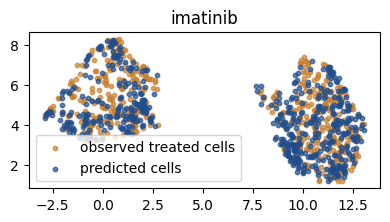

In [13]:
drug = "imatinib"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=1000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post, median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

X_pre cells: (10995, 48)
X_post cells: (2693, 48)
(2154, 48)
(539, 48)
(2154, 48)
(539, 48)


VERS torch=1.13.1+cu117 (CellOT), device=cuda
[CellOT] epoch=0 f_loss=3.3159 g_loss=-21.7215 | train mmd=0.0160 | test_mmd=0.0844


Median heuristic gamma: 0.07603466947967093
**************** Run: 0 ****************


[CellOT] epoch=50 f_loss=-48.2577 g_loss=-38.7750 | train mmd=0.0095 | test_mmd=0.3636
[CellOT] epoch=100 f_loss=-20.0057 g_loss=-33.7148 | train mmd=0.0095 | test_mmd=0.3496
[CellOT] epoch=150 f_loss=-10.8176 g_loss=-25.1844 | train mmd=0.0095 | test_mmd=0.1951
[CellOT] epoch=200 f_loss=-10.2784 g_loss=-21.0652 | train mmd=0.0088 | test_mmd=0.0746
[CellOT] epoch=250 f_loss=-6.8755 g_loss=-18.8583 | train mmd=0.0082 | test_mmd=0.0448
[CellOT] epoch=300 f_loss=-4.5686 g_loss=-17.8782 | train mmd=0.0072 | test_mmd=0.0328
[CellOT] epoch=350 f_loss=-2.0252 g_loss=-19.4419 | train mmd=0.0068 | test_mmd=0.0231
[CellOT] epoch=400 f_loss=0.4705 g_loss=-15.9351 | train mmd=0.0064 | test_mmd=0.0224
[CellOT] epoch=450 f_loss=2.0063 g_loss=-17.5192 | train mmd=0.0056 | test_mmd=0.0155
[CellOT] epoch=500 f_loss=0.4453 g_loss=-20.0226 | train mmd=0.0053 | test_mmd=0.0138
[CellOT] epoch=550 f_loss=0.2584 g_loss=-21.4809 | train mmd=0.0049 | test_mmd=0.0133
[CellOT] epoch=600 f_loss=-2.0381 g_loss=-16

Run 0 metrics: {'mmd2_gamma_median': 0.007220623834779838, 'mmd2_gamma_0.5': 0.0078386512206065, 'mmd2_gamma_1.0': 0.005609477475135087, 'wasserstein_distance': 2.113060761498865, 'R2_feature_means': 0.8106539727653876}
**************** Run: 1 ****************


...

[CellOT] epoch=0 f_loss=5.8871 g_loss=-21.6512 | train mmd=0.0246 | test_mmd=0.1671
[CellOT] epoch=50 f_loss=-62.3196 g_loss=-64.5159 | train mmd=0.0095 | test_mmd=0.3692
[CellOT] epoch=100 f_loss=-32.9324 g_loss=-26.2483 | train mmd=0.0095 | test_mmd=0.3312
[CellOT] epoch=150 f_loss=-11.6596 g_loss=-22.7081 | train mmd=0.0095 | test_mmd=0.2369
[CellOT] epoch=200 f_loss=-7.4476 g_loss=-20.7892 | train mmd=0.0091 | test_mmd=0.0854
[CellOT] epoch=250 f_loss=-3.4701 g_loss=-22.6656 | train mmd=0.0083 | test_mmd=0.0462
[CellOT] epoch=300 f_loss=-2.0672 g_loss=-16.9873 | train mmd=0.0073 | test_mmd=0.0265
[CellOT] epoch=350 f_loss=0.5190 g_loss=-19.2762 | train mmd=0.0064 | test_mmd=0.0166
[CellOT] epoch=400 f_loss=2.1668 g_loss=-22.3089 | train mmd=0.0060 | test_mmd=0.0130
[CellOT] epoch=450 f_loss=-2.2061 g_loss=-18.2902 | train mmd=0.0058 | test_mmd=0.0141
[CellOT] epoch=500 f_loss=-2.4035 g_loss=-14.2093 | train mmd=0.0053 | test_mmd=0.0114
[CellOT] epoch=550 f_loss=-2.9723 g_loss=-16.0

Run 8 metrics: {'mmd2_gamma_median': 0.010334802729173309, 'mmd2_gamma_0.5': 0.01060856723906585, 'mmd2_gamma_1.0': 0.0066433727941816855, 'wasserstein_distance': 2.081819017954443, 'R2_feature_means': 0.7285301848558274}
**************** Run: 9 ****************


[CellOT] epoch=0 f_loss=8.3565 g_loss=-23.5279 | train mmd=0.0216 | test_mmd=0.1969
[CellOT] epoch=50 f_loss=-57.3623 g_loss=-60.3008 | train mmd=0.0095 | test_mmd=0.3685
[CellOT] epoch=100 f_loss=-34.2652 g_loss=-26.6876 | train mmd=0.0095 | test_mmd=0.3395
[CellOT] epoch=150 f_loss=-15.0490 g_loss=-19.6227 | train mmd=0.0095 | test_mmd=0.1703
[CellOT] epoch=200 f_loss=-6.6132 g_loss=-19.9317 | train mmd=0.0091 | test_mmd=0.0710
[CellOT] epoch=250 f_loss=-3.1630 g_loss=-18.3360 | train mmd=0.0082 | test_mmd=0.0349
[CellOT] epoch=300 f_loss=-2.7045 g_loss=-19.8036 | train mmd=0.0071 | test_mmd=0.0237
[CellOT] epoch=350 f_loss=-3.4189 g_loss=-20.6863 | train mmd=0.0066 | test_mmd=0.0186
[CellOT] epoch=400 f_loss=-1.5280 g_loss=-17.4300 | train mmd=0.0064 | test_mmd=0.0180
[CellOT] epoch=450 f_loss=-0.7515 g_loss=-17.4974 | train mmd=0.0066 | test_mmd=0.0214
[CellOT] epoch=500 f_loss=-0.2141 g_loss=-15.9060 | train mmd=0.0049 | test_mmd=0.0106
[CellOT] epoch=550 f_loss=-0.6598 g_loss=-17

Run 9 metrics: {'mmd2_gamma_median': 0.008782038596824804, 'mmd2_gamma_0.5': 0.00825642735004884, 'mmd2_gamma_1.0': 0.00597267570620299, 'wasserstein_distance': 2.259459476476999, 'R2_feature_means': 0.6810118998277157}
                        mean     std
mmd2_gamma_median     0.0076  0.0016
mmd2_gamma_0.5        0.0082  0.0010
mmd2_gamma_1.0        0.0058  0.0004
wasserstein_distance  2.1469  0.0591
R2_feature_means      0.7742  0.0837


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


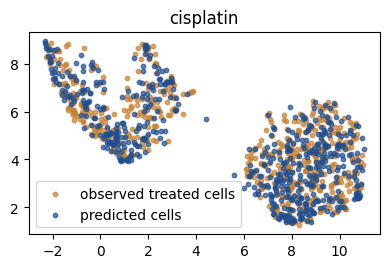

In [14]:
drug = "cisplatin"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=1000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post, median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

X_pre cells: (10995, 48)
X_post cells: (2796, 48)
(2236, 48)
(560, 48)
(2236, 48)
(560, 48)


VERS torch=1.13.1+cu117 (CellOT), device=cuda
[CellOT] epoch=0 f_loss=4.2520 g_loss=-22.1461 | train mmd=0.0169 | test_mmd=0.1379


Median heuristic gamma: 0.074449069228528
**************** Run: 0 ****************


[CellOT] epoch=50 f_loss=-50.8781 g_loss=-45.3711 | train mmd=0.0089 | test_mmd=0.3743
[CellOT] epoch=100 f_loss=-34.0888 g_loss=-38.9261 | train mmd=0.0089 | test_mmd=0.3653
[CellOT] epoch=150 f_loss=-13.6125 g_loss=-21.3325 | train mmd=0.0088 | test_mmd=0.1967
[CellOT] epoch=200 f_loss=-4.3906 g_loss=-26.1326 | train mmd=0.0079 | test_mmd=0.0509
[CellOT] epoch=250 f_loss=-3.2497 g_loss=-18.5222 | train mmd=0.0069 | test_mmd=0.0237
[CellOT] epoch=300 f_loss=-1.7336 g_loss=-18.5779 | train mmd=0.0063 | test_mmd=0.0265
[CellOT] epoch=350 f_loss=-0.2465 g_loss=-19.0863 | train mmd=0.0057 | test_mmd=0.0148
[CellOT] epoch=400 f_loss=-2.1454 g_loss=-19.5254 | train mmd=0.0060 | test_mmd=0.0205
[CellOT] epoch=450 f_loss=-2.6862 g_loss=-18.4395 | train mmd=0.0055 | test_mmd=0.0133
[CellOT] epoch=500 f_loss=0.0147 g_loss=-18.9072 | train mmd=0.0048 | test_mmd=0.0120
[CellOT] epoch=550 f_loss=-1.8500 g_loss=-16.4567 | train mmd=0.0043 | test_mmd=0.0099
[CellOT] epoch=600 f_loss=-2.2499 g_loss=-

Run 0 metrics: {'mmd2_gamma_median': 0.0042129061187768935, 'mmd2_gamma_0.5': 0.008491672101164222, 'mmd2_gamma_1.0': 0.006443584865053514, 'wasserstein_distance': 2.132184245024767, 'R2_feature_means': 0.9451230702537583}
**************** Run: 1 ****************


...

[CellOT] epoch=0 f_loss=4.6580 g_loss=-21.8326 | train mmd=0.0219 | test_mmd=0.1455
[CellOT] epoch=50 f_loss=-65.4934 g_loss=-52.1490 | train mmd=0.0089 | test_mmd=0.3767
[CellOT] epoch=100 f_loss=-31.0241 g_loss=-27.0149 | train mmd=0.0089 | test_mmd=0.3373
[CellOT] epoch=150 f_loss=-13.7294 g_loss=-26.2777 | train mmd=0.0088 | test_mmd=0.1896
[CellOT] epoch=200 f_loss=-5.8855 g_loss=-20.8037 | train mmd=0.0083 | test_mmd=0.0705
[CellOT] epoch=250 f_loss=-2.2535 g_loss=-19.1383 | train mmd=0.0073 | test_mmd=0.0340
[CellOT] epoch=300 f_loss=-2.7002 g_loss=-18.0102 | train mmd=0.0063 | test_mmd=0.0219
[CellOT] epoch=350 f_loss=-6.6498 g_loss=-16.1733 | train mmd=0.0061 | test_mmd=0.0161
[CellOT] epoch=400 f_loss=0.1476 g_loss=-17.2348 | train mmd=0.0057 | test_mmd=0.0137
[CellOT] epoch=450 f_loss=0.3810 g_loss=-17.3651 | train mmd=0.0057 | test_mmd=0.0150
[CellOT] epoch=500 f_loss=0.0558 g_loss=-17.5904 | train mmd=0.0044 | test_mmd=0.0093
[CellOT] epoch=550 f_loss=-5.7483 g_loss=-15.73

Run 8 metrics: {'mmd2_gamma_median': 0.009196663237056923, 'mmd2_gamma_0.5': 0.010901824787408254, 'mmd2_gamma_1.0': 0.0070163511245948, 'wasserstein_distance': 2.1768455525980834, 'R2_feature_means': 0.8258174173741041}
**************** Run: 9 ****************


[CellOT] epoch=50 f_loss=-86.3235 g_loss=-44.4271 | train mmd=0.0089 | test_mmd=0.3769
[CellOT] epoch=100 f_loss=-28.3695 g_loss=-35.2738 | train mmd=0.0089 | test_mmd=0.3438
[CellOT] epoch=150 f_loss=-9.6978 g_loss=-21.1459 | train mmd=0.0088 | test_mmd=0.1939
[CellOT] epoch=200 f_loss=-5.3140 g_loss=-22.9129 | train mmd=0.0083 | test_mmd=0.0663
[CellOT] epoch=250 f_loss=-1.3158 g_loss=-20.0230 | train mmd=0.0073 | test_mmd=0.0345
[CellOT] epoch=300 f_loss=-4.1403 g_loss=-15.3555 | train mmd=0.0070 | test_mmd=0.0235
[CellOT] epoch=350 f_loss=0.4090 g_loss=-22.7968 | train mmd=0.0068 | test_mmd=0.0229
[CellOT] epoch=400 f_loss=-0.1186 g_loss=-17.6655 | train mmd=0.0066 | test_mmd=0.0240
[CellOT] epoch=450 f_loss=-1.3333 g_loss=-18.2843 | train mmd=0.0054 | test_mmd=0.0166
[CellOT] epoch=500 f_loss=1.9370 g_loss=-17.0234 | train mmd=0.0054 | test_mmd=0.0127
[CellOT] epoch=550 f_loss=-2.5331 g_loss=-16.3311 | train mmd=0.0048 | test_mmd=0.0129
[CellOT] epoch=600 f_loss=-3.8429 g_loss=-15

Run 9 metrics: {'mmd2_gamma_median': 0.0073104804948731505, 'mmd2_gamma_0.5': 0.010410235808543444, 'mmd2_gamma_1.0': 0.007040817623447271, 'wasserstein_distance': 2.2373903390523258, 'R2_feature_means': 0.8977655263425794}
                        mean     std
mmd2_gamma_median     0.0075  0.0020
mmd2_gamma_0.5        0.0107  0.0015
mmd2_gamma_1.0        0.0072  0.0006
wasserstein_distance  2.2161  0.0619
R2_feature_means      0.8865  0.0451


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


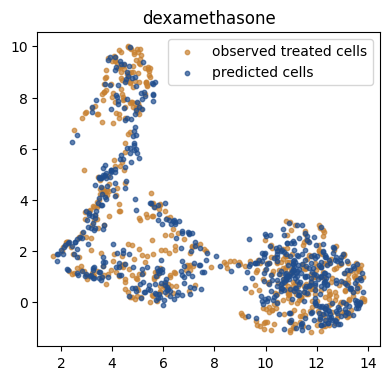

In [15]:
drug = "dexamethasone"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, n_epochs=1000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post, median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)